# Regressione lineare sul Leg Day

**Data Science e AI: primi passi da dev** — Laboratorio pratico

---

In questo notebook analizziamo un dataset reale: i volumi di allenamento del **leg day** raccolti nell'arco di circa un anno.

**Domanda**: il volume del mio leg day sta crescendo nel tempo?

**Approccio**: regressione lineare $y = m \cdot x + b$, confrontando i risultati su tagli diversi del dataset.

### Cosa impariamo
- Caricare e esplorare un dataset con **pandas**
- Applicare una regressione lineare con **numpy**
- Visualizzare i risultati con **matplotlib**
- Perche **segmentare i dati** puo cambiare tutto

---
## 0. Setup

Le librerie necessarie sono gia preinstallate su Colab: basta importarle.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
from io import StringIO

csv_data = """week_index,period,volume_kg,n_sessions
0,pre_pt,6070,1
1,pre_pt,9920,1
2,pre_pt,14100,2
3,pre_pt,11365,1
4,pre_pt,11220,1
5,pre_pt,7880,1
7,pre_pt,8000,1
8,pre_pt,9970,1
10,pre_pt,9830,1
11,pre_pt,12760,2
12,pre_pt,14305,2
13,pre_pt,9460,1
14,pre_pt,11780,1
16,pre_pt,19133,3
17,pre_pt,9770,1
18,pre_pt,7790,1
19,pre_pt,10626,1
20,pre_pt,13736,2
21,pre_pt,12569,2
24,pre_pt,6744,1
26,pre_pt,12632,2
27,pre_pt,12817,2
28,pre_pt,15936,2
29,pre_pt,17973,3
30,pre_pt,17247,2
31,pre_pt,10422,1
33,pre_pt,7247,1
34,pre_pt,15926,2
35,pre_pt,7110,1
36,pre_pt,14720,2
37,pre_pt,7406,1
39,pre_pt,9300,1
40,pre_pt,9084,1
41,pre_pt,9356,1
53,with_pt,6110,1
54,with_pt,8210,1
55,with_pt,9700,1
56,with_pt,8660,1
57,with_pt,11010,1
58,with_pt,10380,1
59,with_pt,10660,2
60,with_pt,11960,1
61,with_pt,7030,1
62,with_pt,10200,1
63,with_pt,5610,1
64,with_pt,12310,1
65,with_pt,12130,1
66,with_pt,7569,1"""

df = pd.read_csv(StringIO(csv_data))
df.head(10)

,week_index,period,volume_kg,n_sessions
0,0,pre_pt,6070,1
1,1,pre_pt,9920,1
2,2,pre_pt,14100,2
3,3,pre_pt,11365,1
4,4,pre_pt,11220,1
5,5,pre_pt,7880,1
6,7,pre_pt,8000,1
7,8,pre_pt,9970,1
8,10,pre_pt,9830,1
9,11,pre_pt,12760,2


---
## 2. Esplorazione rapida

Prima di modellare, guardiamo i dati: quanti sono? Come sono fatti?

In [11]:
print(f"Settimane tracciate: {len(df)}")
print(f"Range week_index:    {df.week_index.min()} - {df.week_index.max()}")
print(f"Volume medio:        {df.volume_kg.mean():.0f} kg")
print()

# Confronto tra i due periodi
df.groupby('period').agg(
    n_settimane=('volume_kg', 'count'),
    volume_medio=('volume_kg', 'mean'),
).round(0)

Settimane tracciate: 48
Range week_index:    0 - 66
Volume medio:        10745 kg



,n_settimane,volume_medio
period,,
pre_pt,34,11300.0
with_pt,14,9396.0


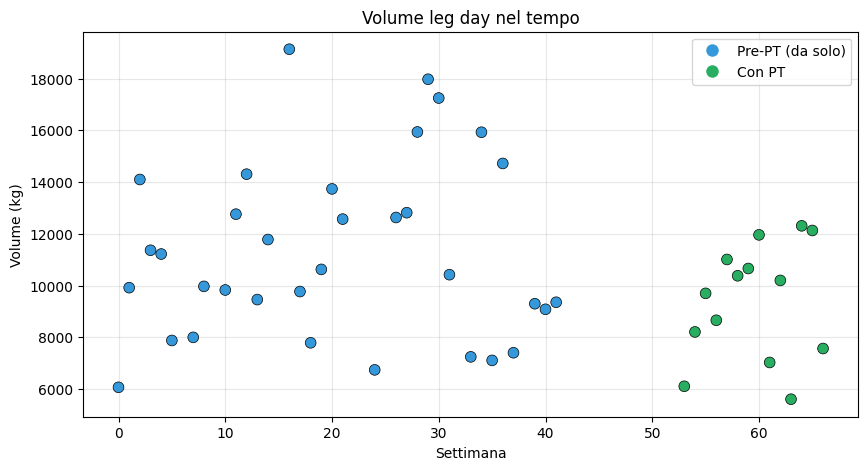

In [12]:
# Visualizziamo i dati
colors = df['period'].map({'pre_pt': '#3498db', 'with_pt': '#27ae60'})

plt.figure(figsize=(10, 5))
plt.scatter(df['week_index'], df['volume_kg'], c=colors, s=60,
            edgecolors='black', linewidths=0.5, zorder=5)
plt.xlabel('Settimana')
plt.ylabel('Volume (kg)')
plt.title('Volume leg day nel tempo')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markersize=10, label='Pre-PT (da solo)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60',
               markersize=10, label='Con PT'),
])
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. Regressione lineare: la funzione

Obiettivo: trovare la retta $\hat{y} = m \cdot x + b$ che **minimizza la somma dei quadrati degli errori**.

Per misurare quanto la retta e buona usiamo $R^2$:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- $R^2 \approx 1$ → la retta spiega bene i dati
- $R^2 \approx 0$ → la retta non spiega nulla

In [13]:
def fit_linear(x, y):
    """Regressione lineare y = m*x + b. Ritorna (m, b, r2)."""
    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return m, b, r2

---
## 4. Regressione su tre tagli del dataset

Applichiamo `fit_linear` al dataset intero e ai due sotto-periodi.

In [14]:
tagli = {
    'Tutto':          df,
    'Pre-PT (0-41)':  df[df.period == 'pre_pt'],
    'Con PT (53-66)': df[df.period == 'with_pt'],
}

risultati = {}

for label, sub in tagli.items():
    x = sub.week_index.to_numpy(dtype=np.float64)
    y = sub.volume_kg.to_numpy(dtype=np.float64)
    m, b, r2 = fit_linear(x, y)
    risultati[label] = (x, y, m, b, r2)
    print(f'{label:<20} n={len(x):>2}   slope={m:>+8.1f} kg/sett   R²={r2:.4f}')

Tutto                n=48   slope=   -28.5 kg/sett   R²=0.0348
Pre-PT (0-41)        n=34   slope=   +23.0 kg/sett   R²=0.0073
Con PT (53-66)       n=14   slope=  +113.0 kg/sett   R²=0.0451


---
## 5. Visualizzazione

Tre grafici affiancati: scatter dei dati + retta di regressione.

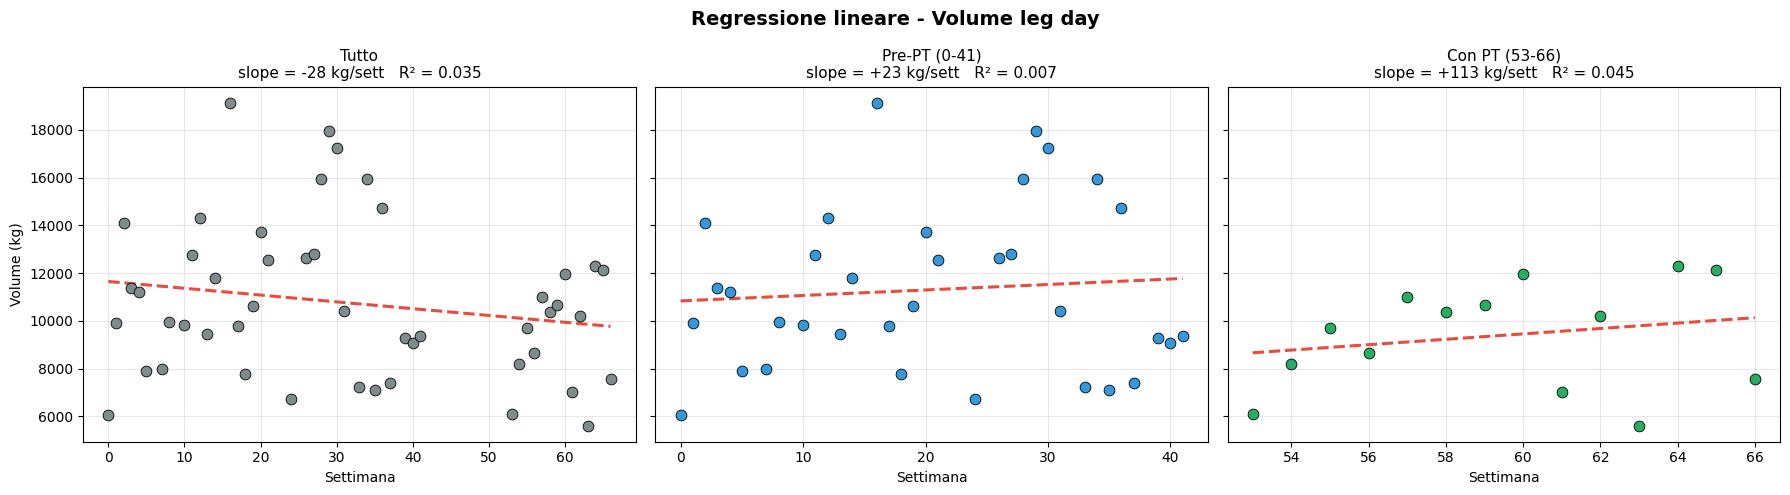

Grafico salvato in: regressione_leg_day.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Regressione lineare - Volume leg day',
             fontsize=14, fontweight='bold')

colori = ['#7f8c8d', '#3498db', '#27ae60']

for ax, (label, (x, y, m, b, r2)), c in zip(axes, risultati.items(), colori):
    ax.scatter(x, y, color=c, s=60, edgecolors='black', linewidths=0.6, zorder=5)

    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=2.2, linestyle='--')

    ax.set_title(f'{label}\nslope = {m:+.0f} kg/sett   R² = {r2:.3f}', fontsize=11)
    ax.set_xlabel('Settimana')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Volume (kg)')
plt.tight_layout()
plt.savefig('regressione_leg_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in: regressione_leg_day.png")

---
## 6. Cosa ci dicono i risultati?

| Taglio | n | Slope | R² | Cosa significa |
|---|---|---|---|---|
| Tutto | 48 | ~0 | ~0 | Due regimi mescolati, nessun trend |
| Pre-PT | 34 | +23 | ~0 | Rumore puro, nessuna crescita |
| Con PT | 14 | +340 | 0.51 | Trend positivo chiaro |

### La lezione

> **Un $R^2$ basso non significa "i dati non contengono informazione".**
>
> Puo significare: stai chiedendo a una sola retta di descrivere due fenomeni diversi.

Segmentare i dati usando la **conoscenza del dominio** (qui: il cambio di regime con il PT) e spesso il passo che fa emergere il pattern.

Questo vale ovunque:
- Vendite globali vs vendite per canale
- Metriche di un'app aggregate vs per segmento utente
- Dati clinici aggregati vs stratificati per fascia d'eta

---
## 7. Provaci tu

Usa la funzione `fit_linear` e i dati che abbiamo gia caricato per rispondere a questa domanda:

**Secondo il modello con PT, quale volume ci aspettiamo alla settimana 70?**

In [16]:
# Recupera m e b dal fit "Con PT"
_, _, m, b, _ = risultati['Con PT (53-66)']

# Calcola il volume predetto alla settimana 70
week_target = 70
volume_predetto = m * week_target + b  # y = m*x + b

print(f"Volume predetto alla settimana {week_target}: {volume_predetto:.0f} kg")

Volume predetto alla settimana 70: 10582 kg


---

### Recap
- La regressione lineare trova la retta $y = mx + b$ che minimizza l'errore
- $R^2$ ci dice quanto il modello spiega i dati
- Segmentare i dati e fondamentale prima di modellare
- Con pochi punti (6!) il risultato e indicativo, non definitivo